In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches

from sklearn.metrics import r2_score
from scipy.stats import pearsonr
sns.set_theme(style="whitegrid")

## Binary PSI

In [2]:
binary_splice_performances = {
    'BPsiRandomForest': {'MCC': 0.12, 'AUC': 0.56, 'Balanced Accuracy': 0.56, 'F1 Score': 0.41, 'note': 'proper splits'},
    'BPsiHistoneConvSE+AR': {'MCC': 0.27, 'AUC': 0.75, 'Balanced Accuracy': 0.67, 'F1 Score': 0.89, 'note': ''},
    'BPsiHistoneConvSE': {'MCC': 0.20, 'AUC': 0.64, 'Balanced Accuracy': 0.60, 'F1 Score': 0.62, 'note': '+-70bp around the junction -> same for 120bp'},
    'BPsiMergedCellLineSE': {'MCC': 0.36, 'AUC': 0.73, 'Balanced Accuracy': 0.67, 'F1 Score': 0.73, 'note': 'Also conv model'},
    'BPsiESPRNNSE': {'MCC': 0.11, 'AUC': 0.57, 'Balanced Accuracy': 0.55, 'F1 Score': 0.60, 'note': 'model adapted from keras'},
    'BPsiESPRNNNaiveSE': {'MCC': 0.30, 'AUC': 0.71, 'Balanced Accuracy': 0.65, 'F1 Score': 0.70, 'note': 'Naive data splits'},
    'BPsiESPRNNNormSE': {'MCC': 0.34, 'AUC': 0.75, 'Balanced Accuracy': 0.66, 'F1 Score': 0.72, 'note': 'Normalization across all data'},
    'BPsiFullSE': {'MCC': 0.20, 'AUC': 0.64, 'Balanced Accuracy': 0.60, 'F1 Score': 0.67, 'note': 'Full model with seq encoder and attention'},
    'BPsiFullSE+AR': {'MCC': 0.26, 'AUC': 0.68, 'Balanced Accuracy': 0.63, 'F1 Score': 0.66, 'note': ''}
    }

b_psi_df = pd.DataFrame(binary_splice_performances)
b_psi_df

,BPsiRandomForest,BPsiHistoneConvSE+AR,BPsiHistoneConvSE,BPsiMergedCellLineSE,BPsiESPRNNSE,BPsiESPRNNNaiveSE,BPsiESPRNNNormSE,BPsiFullSE,BPsiFullSE+AR
MCC,0.12,0.27,0.2,0.36,0.11,0.3,0.34,0.2,0.26
AUC,0.56,0.75,0.64,0.73,0.57,0.71,0.75,0.64,0.68
Balanced Accuracy,0.56,0.67,0.6,0.67,0.55,0.65,0.66,0.6,0.63
F1 Score,0.41,0.89,0.62,0.73,0.6,0.7,0.72,0.67,0.66
note,proper splits,,+-70bp around the junction -> same for 120bp,Also conv model,model adapted from keras,Naive data splits,Normalization across all data,Full model with seq encoder and attention,


In [3]:
b_psi_df = b_psi_df.reset_index().melt(id_vars="index", var_name="Model", value_name="Score")
b_psi_df.rename(columns={"index": "Metric"}, inplace=True)

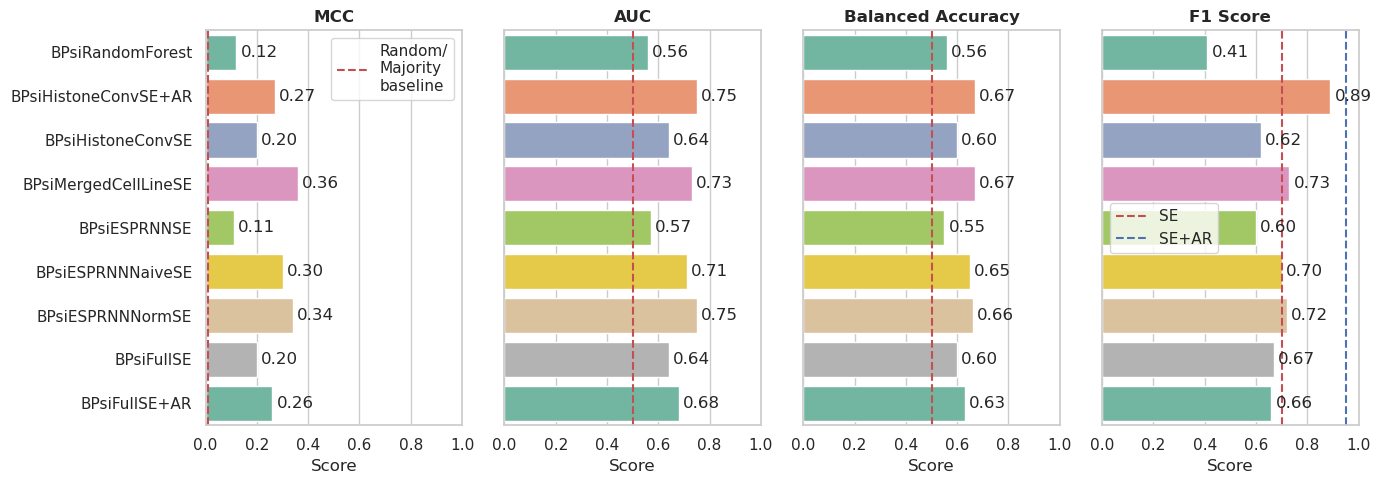

In [4]:
# plot per metric
palette = sns.color_palette("Set2", n_colors=b_psi_df["Model"].nunique())
fig, ax = plt.subplots(1, 4, figsize=(14, 5), sharey=True)
axes = ax.flatten()

metrics = b_psi_df["Metric"].unique()

zero_pos = {'MCC': 0.01, 'AUC': 0.5, 'Balanced Accuracy': 0.5, 'F1 Score': (0.70, 0.95)}


for i, metric in enumerate(metrics):
    if metric == 'note':
        continue
    ax = axes[i]
    sns.barplot(
        data=b_psi_df[b_psi_df["Metric"] == metric],
        x="Score", y="Model", ax=ax, orient="h",
        hue="Model", dodge=False, palette=palette
    )
    ax.set_title(metric, fontsize=12, weight="bold")
    ax.set_xlim(0, 1)
    ax.set_xlabel("Score")
    ax.set_ylabel("")  # remove redundant label
    if metric == 'F1 Score':
        ax.axvline(x=zero_pos[metric][0], color='r', linestyle='--', label=("SE"))
        ax.axvline(x=zero_pos[metric][1], color='b', linestyle='--', label="SE+AR")
    else:
        ax.axvline(x=zero_pos[metric], color='r', linestyle='--', label='Random/\nMajority\nbaseline')
    if metric == "MCC" or metric == "F1 Score":
        ax.legend()
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", label_type="edge", padding=3)

handles, labels = ax.get_legend_handles_labels()
#fig.legend(handles, labels, loc="lower center", ncol=len(labels), frameon=False)

plt.tight_layout()
plt.savefig("../images/bpsi_performances.png", dpi=300)
plt.show()

## EPInformer replication

In [5]:
epinformer_performances = {
    'PE-Activity-HiC': {'Pearson r': 0.86, 'group': 'full'},
    'Rep-PE-Activity-HiC': {'Pearson r': 0.86, 'group': 'full'},
    'PE-Activity-HiC-0Enh': {'Pearson r': 0.86, 'group': 'full'},
    
    'PE': {'Pearson r': 0.72, 'group': 'promoter seq'},
    'PE-0Enh': {'Pearson r': 0.64, 'group': 'promoter seq'}, # aligns with their Promoter only test
    
    'PE-Activity': {'Pearson r': 0.84, 'group': 'promoter activity'},
    'PE-Activity-0Enh': {'Pearson r': 0.86, 'group': 'promoter activity'},
    'Activity': {'Pearson r': 0.71, 'group': 'promoter activity'},

    'PE-Activity-HiC-0Enh-0HL': {'Pearson r': 0.85, 'group': 'no half-life'},
}

epinf_df = pd.DataFrame(epinformer_performances)
epinf_df

,PE-Activity-HiC,Rep-PE-Activity-HiC,PE-Activity-HiC-0Enh,PE,PE-0Enh,PE-Activity,PE-Activity-0Enh,Activity,PE-Activity-HiC-0Enh-0HL
Pearson r,0.86,0.86,0.86,0.72,0.64,0.84,0.86,0.71,0.85
group,full,full,full,promoter seq,promoter seq,promoter activity,promoter activity,promoter activity,no half-life


In [6]:
epinf_df = epinf_df.T.reset_index()
epinf_df.rename(columns={"index": "Model"}, inplace=True)
epinf_df

,Model,Pearson r,group
0,PE-Activity-HiC,0.86,full
1,Rep-PE-Activity-HiC,0.86,full
2,PE-Activity-HiC-0Enh,0.86,full
3,PE,0.72,promoter seq
4,PE-0Enh,0.64,promoter seq
5,PE-Activity,0.84,promoter activity
6,PE-Activity-0Enh,0.86,promoter activity
7,Activity,0.71,promoter activity
8,PE-Activity-HiC-0Enh-0HL,0.85,no half-life


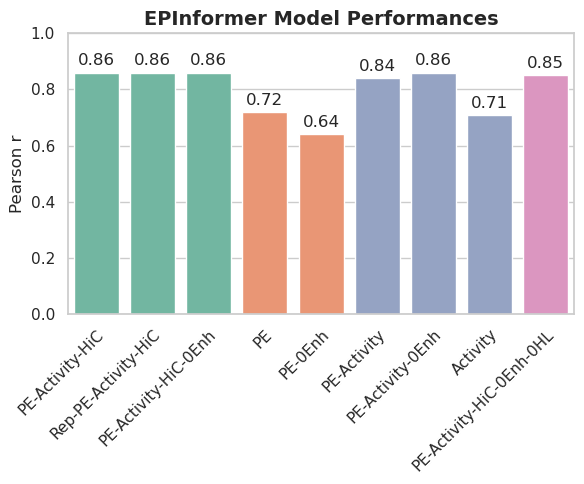

In [7]:
palette = sns.color_palette("Set2", n_colors=epinf_df["group"].nunique())
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
sns.barplot(
    data=epinf_df,
    x="Model", y="Pearson r", ax=ax, orient="v",
    hue="group", dodge=False, palette=palette
)
ax.set_title("EPInformer Model Performances", fontsize=14, weight="bold")
ax.set_ylim(0, 1)
#ax.set_xlabel("Pearson r")
ax.set_xlabel("")  # remove redundant label
ax.tick_params(axis='x', rotation=45)
for label in ax.get_xticklabels():
    label.set_horizontalalignment('right')
    label.set_rotation_mode('anchor')
ax.legend([],[], frameon=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge", padding=3)
plt.tight_layout()
plt.savefig("../images/epinformer_performances.png", dpi=300)
plt.show()

In [8]:
response = "../data/GM12878_K562_18377_gene_expr_fromXpresso.csv"
response_df = pd.read_csv(response, index_col=0)
response_df = response_df[['Actual_K562']]

activity_k562 = pd.read_csv('../data/IHEC-ChIP-Seq-Histone-Signals/PromotersK562.H3K27ac.tab', sep='\t', names=['gene_id', 'size', 'covered', 'sum', 'mean0', 'mean'])
# drop rows where covered is less than 1000
activity_k562 = activity_k562[activity_k562['covered'] >= 1000]
activity_k562 = activity_k562[['gene_id', 'mean']]

merged_df = response_df.merge(activity_k562, left_index=True, right_on='gene_id', how='inner')
merged_df.rename(columns={'mean': 'H3K27ac_activity'}, inplace=True)
merged_df

,Actual_K562,gene_id,H3K27ac_activity
18043,-0.638913,ENSG00000000003,0.272761
18042,-1.146680,ENSG00000000005,0.194351
16886,1.529660,ENSG00000000419,21.547500
1419,0.608184,ENSG00000000457,26.697300
1418,1.038466,ENSG00000000460,18.810500
...,...,...,...
16744,1.831873,ENSG00000259399,7.191920
12037,-0.068791,ENSG00000259431,15.745600
12980,0.148647,ENSG00000259511,0.113938
10548,-1.170504,ENSG00000259571,0.000000


In [9]:
# mean expression
mean_expr = merged_df['Actual_K562'].mean()
mean_expr

np.float64(2.580823787880239e-05)

In [10]:
se_events = pd.read_csv('../data/psi_response.csv')
se_events = se_events[se_events['event_id'].str.contains(';SE:')]
se_genes = set(se_events['gene_id'].unique())

/tmp/ipykernel_1845855/1772586438.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


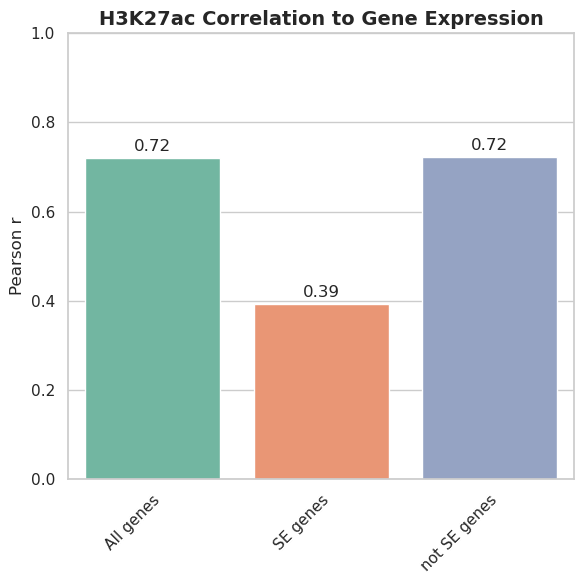

In [11]:
# calculate pearson correlation
from scipy.stats import pearsonr
pearson_r, p_value = pearsonr(merged_df['Actual_K562'], merged_df['H3K27ac_activity'])

# do the same but split for SE and non-SE genes
merged_df_se = merged_df[merged_df['gene_id'].isin(se_genes)]
pearson_r_se, p_value_se = pearsonr(merged_df_se['Actual_K562'], merged_df_se['H3K27ac_activity'])

merged_df_no_se = merged_df[~merged_df['gene_id'].isin(se_genes)]
pearson_r_no_se, p_value_no_se = pearsonr(merged_df_no_se['Actual_K562'], merged_df_no_se['H3K27ac_activity'])

# barplot time
correlation_df = pd.DataFrame({
    'Gene Type': ['All genes', 'SE genes', 'not SE genes'],
    'Pearson r': [pearson_r, pearson_r_se, pearson_r_no_se]
})

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
sns.barplot(
    data=correlation_df,
    x="Gene Type", y="Pearson r", ax=ax, orient="v", legend=False,
    palette="Set2"
)
ax.set_title("H3K27ac Correlation to Gene Expression", fontsize=14, weight="bold")
ax.set_ylim(0, 1)
ax.set_xlabel("")  # remove redundant label
for label in ax.get_xticklabels():
    label.set_horizontalalignment('right')
    label.set_rotation_mode('anchor')
ax.tick_params(axis='x', rotation=45)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge", padding=3)
plt.tight_layout()
# plt.savefig("../images/k562_activity_expression_correlation.png", dpi=300)
plt.show()

In [12]:
SS_tot_all = np.sum((merged_df['Actual_K562'] - merged_df['Actual_K562'].mean())**2)
SS_tot_se = np.sum((merged_df_se['Actual_K562'] - merged_df_se['Actual_K562'].mean())**2)
SS_tot_no_se = np.sum((merged_df_no_se['Actual_K562'] - merged_df_no_se['Actual_K562'].mean())**2)

SS_tot_all, SS_tot_se, SS_tot_no_se

(np.float64(18376.775072630237),
 np.float64(888.5448834103196),
 np.float64(13398.267727759456))

## Simple event addition

In [13]:
simple_event_performances = {
    'BaseExprOnly': {'r_expr': 0.76, 'r2_expr': 0.53, 'r_psi': 0, 'r2_psi': 0, 'note': 'Multitask model training only expression'},
    'BasePsiOnly': {'r_expr': 0, 'r2_expr': 0, 'r_psi': 0.31, 'r2_psi': 0.08, 'note': 'Multitask model training only psi'},
    'BaseExpr+Psi': {'r_expr': 0.77, 'r2_expr': 0.58, 'r_psi': 0.36, 'r2_psi': 0.13, 'note': 'Multitask model training both'},
    'BaseStrictAtt': {'r_expr': 0.75, 'r2_expr': 0.56, 'r_psi': 0.28, 'r2_psi': 0.07, 'note': 'Multitask model with strict attention'},
    'Base+EventOnly': {'r_expr': 0.3, 'r2_expr': 0.08, 'r_psi': 0.3, 'r2_psi': 0.08, 'note': 'Multitask model training only events'},
    'Base+P_seqOnly': {'r_expr': 0.43, 'r2_expr': 0.09, 'r_psi': 0.11, 'r2_psi': 0, 'note': 'Promoter seq only'},
    'Base+E_seqOnly': {'r_expr': 0.37, 'r2_expr': 0.04, 'r_psi': 0.06, 'r2_psi': 0, 'note': 'Enhancer seqs only'},
    'Base+0Event': {'r_expr': 0.75, 'r2_expr': 0.54, 'r_psi': 0.14, 'r2_psi': 0.02, 'note': 'Multitask model with 0 event features'},
    'Base+0Enh': {'r_expr': 0.76, 'r2_expr': 0.54, 'r_psi': 0.23, 'r2_psi': 0.05, 'note': 'Multitask without enhancer data'},
    'Base+0PE': {'r_expr': 0.76, 'r2_expr': 0.57, 'r_psi': 0.33, 'r2_psi': 0.09, 'note': 'Multitask with pe seq set to 0'},
}

s_event_df = pd.DataFrame(simple_event_performances)
s_event_df

,BaseExprOnly,BasePsiOnly,BaseExpr+Psi,BaseStrictAtt,Base+EventOnly,Base+P_seqOnly,Base+E_seqOnly,Base+0Event,Base+0Enh,Base+0PE
r_expr,0.76,0,0.77,0.75,0.3,0.43,0.37,0.75,0.76,0.76
r2_expr,0.53,0,0.58,0.56,0.08,0.09,0.04,0.54,0.54,0.57
r_psi,0,0.31,0.36,0.28,0.3,0.11,0.06,0.14,0.23,0.33
r2_psi,0,0.08,0.13,0.07,0.08,0,0,0.02,0.05,0.09
note,Multitask model training only expression,Multitask model training only psi,Multitask model training both,Multitask model with strict attention,Multitask model training only events,Promoter seq only,Enhancer seqs only,Multitask model with 0 event features,Multitask without enhancer data,Multitask with pe seq set to 0


In [14]:
# transform for plotting
s_event_df_melted = s_event_df.reset_index().melt(id_vars="index", var_name="Model", value_name="Score").copy()
s_event_df_melted.rename(columns={"index": "Metric"}, inplace=True)
s_event_df_melted

,Metric,Model,Score
0,r_expr,BaseExprOnly,0.76
1,r2_expr,BaseExprOnly,0.53
2,r_psi,BaseExprOnly,0
3,r2_psi,BaseExprOnly,0
4,note,BaseExprOnly,Multitask model training only expression
5,r_expr,BasePsiOnly,0
6,r2_expr,BasePsiOnly,0
7,r_psi,BasePsiOnly,0.31
8,r2_psi,BasePsiOnly,0.08
9,note,BasePsiOnly,Multitask model training only psi


/tmp/ipykernel_1845855/2713361995.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_yticklabels(yticklabels)
/tmp/ipykernel_1845855/2713361995.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r2_rows['Metric'] = r2_rows['Metric'].map({'r2_expr': 'r² (expression)', 'r2_psi': 'r² (PSI)'})


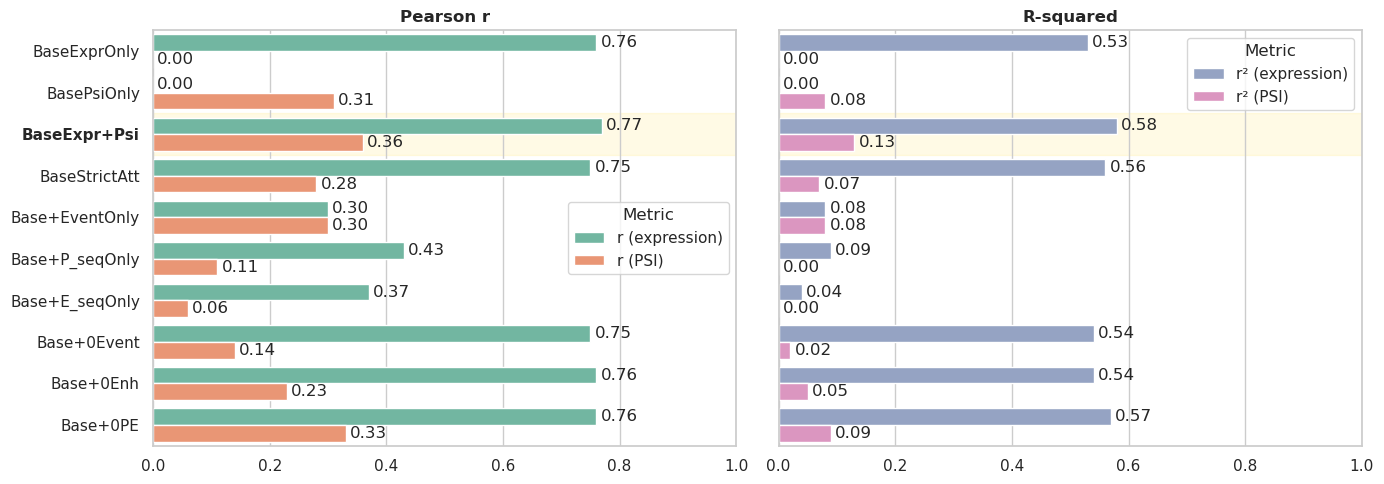

In [15]:
palette = sns.color_palette("Set2", n_colors=4)
palette1 = palette[:2]
palette2 = palette[2:]

fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
axes = ax

pearson_rows = s_event_df_melted[s_event_df_melted["Metric"].isin(['r_expr', 'r_psi'])].copy()
pearson_rows['Metric'] = pearson_rows['Metric'].map({'r_expr': 'r (expression)', 'r_psi': 'r (PSI)'})
sns.barplot(
    data=pearson_rows,
    x="Score", y="Model", ax=axes[0], orient="h",
    hue="Metric", dodge=True, palette=palette1
)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.2f", label_type="edge", padding=3)

model_to_highlight = 'BaseExpr+Psi'
ypos = pearson_rows["Model"].unique().tolist().index(model_to_highlight)

bar_height = 0.5 * len(pearson_rows["Metric"].unique())
main_model = patches.Rectangle(
        (0, ypos - 0.5),          # (x,y) lower-left
        1,                        # full width (since xlim is 0–1)
        bar_height,               # vertical span
        color="gold", alpha=0.1,  # subtle highlight color
        zorder=0                  # behind bars
        )

main_model2 = patches.Rectangle(
        (0, ypos - 0.5),          
        1,                        
        bar_height,               
        color="gold", alpha=0.1,  
        zorder=0                  
        )

# Add rectangle spanning the entire x-axis for that row
axes[0].add_patch(main_model)

yticklabels = axes[0].get_yticklabels()

for label in yticklabels:
    if label.get_text() == model_to_highlight:
        label.set_fontweight("bold")

axes[0].set_yticklabels(yticklabels)

axes[0].set_title("Pearson r", fontsize=12, weight="bold")
axes[0].set_xlim(0, 1)
axes[0].set_xlabel("")
axes[0].set_ylabel("")  # remove redundant label
axes[0].legend(title="Metric", loc="best")

r2_rows = s_event_df_melted[s_event_df_melted["Metric"].isin(['r2_expr', 'r2_psi'])]
r2_rows['Metric'] = r2_rows['Metric'].map({'r2_expr': 'r² (expression)', 'r2_psi': 'r² (PSI)'})
sns.barplot(
    data=r2_rows,
    x="Score", y="Model", ax=axes[1], orient="h",
    hue="Metric", dodge=True, palette=palette2
)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f", label_type="edge", padding=3)

axes[1].add_patch(main_model2)

axes[1].set_title("R-squared", fontsize=12, weight="bold")
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("")
axes[1].set_ylabel("")  # remove redundant label
axes[1].legend(title="Metric", loc="best")

#fig.legend(handles, labels, loc="lower center", ncol=len(labels), frameon=False)
plt.tight_layout()
plt.savefig("../images/simple_event_performances.png", dpi=300)
plt.show()

## Performance with histone marks

In [16]:
hist_perf = {
    'HistReduced': {'r_expr': 0.70, 'r2_expr': 0.49, 'r_psi': 0.32, 'r2_psi': 0.07, 'note': 'Reduced model without mrna & hic'},
    'HistSEOnly': {'r_expr': 0.57, 'r2_expr': 0.31, 'r_psi': 0.11, 'r2_psi': 0.01, 'note': 'Reduced model with only SE samples'},
    'HistPromActivity': {'r_expr': 0.72, 'r2_expr': 0.52, 'r_psi': 0.35, 'r2_psi': 0.11, 'note': 'Our promoter H3K27ac'},
    'HistPromAllMarks': {'r_expr': 0.73, 'r2_expr': 0.51, 'r_psi': 0.36, 'r2_psi': 0.13, 'note': 'Additional promoter hist marks'},
    'HistEnhAllMarks':  {'r_expr': 0.74, 'r2_expr': 0.54, 'r_psi': 0.36, 'r2_psi': 0.12, 'note': 'Enhancer hist marks'},
    'HistEventAllMarks':  {'r_expr': 0.79, 'r2_expr': 0.57, 'r_psi': 0.32, 'r2_psi': 0.1, 'note': 'Event hist marks'},
    'HistJunctions':  {'r_expr': 0.79, 'r2_expr': 0.62, 'r_psi': 0.33, 'r2_psi': 0.11, 'note': 'Use junctions instead of sequences'},   
}

hist_perf_df = pd.DataFrame(hist_perf)
hist_perf_df

,HistReduced,HistSEOnly,HistPromActivity,HistPromAllMarks,HistEnhAllMarks,HistEventAllMarks,HistJunctions
r_expr,0.7,0.57,0.72,0.73,0.74,0.79,0.79
r2_expr,0.49,0.31,0.52,0.51,0.54,0.57,0.62
r_psi,0.32,0.11,0.35,0.36,0.36,0.32,0.33
r2_psi,0.07,0.01,0.11,0.13,0.12,0.1,0.11
note,Reduced model without mrna & hic,Reduced model with only SE samples,Our promoter H3K27ac,Additional promoter hist marks,Enhancer hist marks,Event hist marks,Use junctions instead of sequences


In [17]:
hist_perf_long = hist_perf_df.reset_index().melt(id_vars="index", var_name="Model", value_name="Score").copy()
hist_perf_long.rename(columns={"index": "Metric"}, inplace=True)
hist_perf_long

,Metric,Model,Score
0,r_expr,HistReduced,0.7
1,r2_expr,HistReduced,0.49
2,r_psi,HistReduced,0.32
3,r2_psi,HistReduced,0.07
4,note,HistReduced,Reduced model without mrna & hic
5,r_expr,HistSEOnly,0.57
6,r2_expr,HistSEOnly,0.31
7,r_psi,HistSEOnly,0.11
8,r2_psi,HistSEOnly,0.01
9,note,HistSEOnly,Reduced model with only SE samples


/tmp/ipykernel_1845855/1840235186.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_yticklabels(yticklabels)
/tmp/ipykernel_1845855/1840235186.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r2_rows['Metric'] = r2_rows['Metric'].map({'r2_expr': 'r² (expression)', 'r2_psi': 'r² (PSI)'})


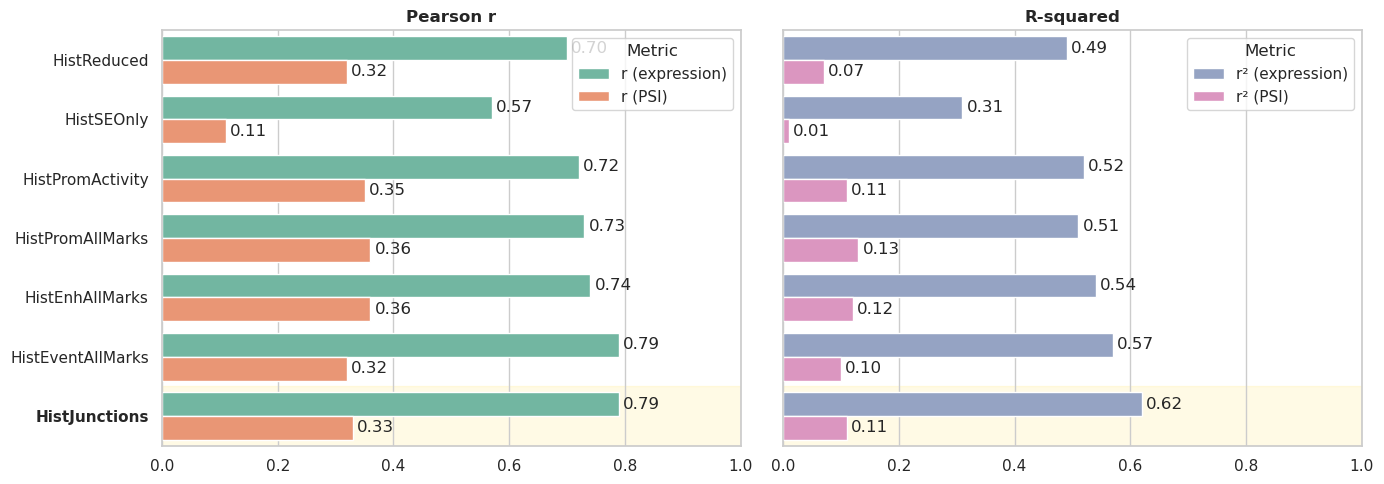

In [18]:
palette = sns.color_palette("Set2", n_colors=4)
palette1 = palette[:2]
palette2 = palette[2:]

fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
axes = ax

pearson_rows = hist_perf_long[hist_perf_long["Metric"].isin(['r_expr', 'r_psi'])].copy()
pearson_rows['Metric'] = pearson_rows['Metric'].map({'r_expr': 'r (expression)', 'r_psi': 'r (PSI)'})
sns.barplot(
    data=pearson_rows,
    x="Score", y="Model", ax=axes[0], orient="h",
    hue="Metric", dodge=True, palette=palette1
)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.2f", label_type="edge", padding=3)

model_to_highlight = 'HistJunctions'
ypos = pearson_rows["Model"].unique().tolist().index(model_to_highlight)

bar_height = 0.5 * len(pearson_rows["Metric"].unique())
main_model = patches.Rectangle(
        (0, ypos - 0.5),          # (x,y) lower-left
        1,                        # full width (since xlim is 0–1)
        bar_height,               # vertical span
        color="gold", alpha=0.1,  # subtle highlight color
        zorder=0                  # behind bars
        )

main_model2 = patches.Rectangle(
        (0, ypos - 0.5),          
        1,                        
        bar_height,               
        color="gold", alpha=0.1,  
        zorder=0                  
        )

# Add rectangle spanning the entire x-axis for that row
axes[0].add_patch(main_model)

yticklabels = axes[0].get_yticklabels()

for label in yticklabels:
    if label.get_text() == model_to_highlight:
        label.set_fontweight("bold")

axes[0].set_yticklabels(yticklabels)

axes[0].set_title("Pearson r", fontsize=12, weight="bold")
axes[0].set_xlim(0, 1)
axes[0].set_xlabel("")
axes[0].set_ylabel("")  # remove redundant label
axes[0].legend(title="Metric", loc="best")

r2_rows = hist_perf_long[hist_perf_long["Metric"].isin(['r2_expr', 'r2_psi'])]
r2_rows['Metric'] = r2_rows['Metric'].map({'r2_expr': 'r² (expression)', 'r2_psi': 'r² (PSI)'})
sns.barplot(
    data=r2_rows,
    x="Score", y="Model", ax=axes[1], orient="h",
    hue="Metric", dodge=True, palette=palette2
)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f", label_type="edge", padding=3)

axes[1].add_patch(main_model2)

axes[1].set_title("R-squared", fontsize=12, weight="bold")
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("")
axes[1].set_ylabel("")  # remove redundant label
axes[1].legend(title="Metric", loc="best")

#fig.legend(handles, labels, loc="lower center", ncol=len(labels), frameon=False)
plt.tight_layout()
plt.savefig("../images/histone_addition_performances.png", dpi=300)
plt.show()

## Base pair level epigenetic integration

In [19]:
epigen_bp_perf = {
    "FullNoHistEncoder": {'r_expr': 0.75, 'r_psi': 0.14, 'r2_expr': 0.53, 'r2_psi': 0.0},
    "FullPSIOnly": {'r_expr': 0.55, 'r_psi': 0.41, 'r2_expr': 0, 'r2_psi': 0.16},
    "FullModel": {'r_expr': 0.78, 'r_psi': 0.44, 'r2_expr': 0.59, 'r2_psi': 0.19},
    "FullNoActivity": {'r_expr': 0.77, 'r_psi': 0.4, 'r2_expr': 0.57, 'r2_psi': 0.16},
    "FullBothCells": {'r_expr': 0.78, 'r_psi': 0.4, 'r2_expr': 0.59, 'r2_psi': 0.16},
}

epigen_bp_fold = {
    "FullAllFoldK562": {},
    "FullAllFoldGM12878": {},
}

epigen_bp_perf = pd.DataFrame(epigen_bp_perf)

In [20]:
epigen_bp_perf_long = epigen_bp_perf.reset_index().melt(id_vars="index", var_name="Model", value_name="Score").copy()
epigen_bp_perf_long.rename(columns={"index": "Metric"}, inplace=True)
epigen_bp_perf_long

,Metric,Model,Score
0,r_expr,FullNoHistEncoder,0.75
1,r_psi,FullNoHistEncoder,0.14
2,r2_expr,FullNoHistEncoder,0.53
3,r2_psi,FullNoHistEncoder,0.00
4,r_expr,FullPSIOnly,0.55
5,r_psi,FullPSIOnly,0.41
6,r2_expr,FullPSIOnly,0.00
7,r2_psi,FullPSIOnly,0.16
8,r_expr,FullModel,0.78
9,r_psi,FullModel,0.44


/tmp/ipykernel_1845855/27929192.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_yticklabels(yticklabels)
/tmp/ipykernel_1845855/27929192.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r2_rows['Metric'] = r2_rows['Metric'].map({'r2_expr': 'r² (expression)', 'r2_psi': 'r² (PSI)'})


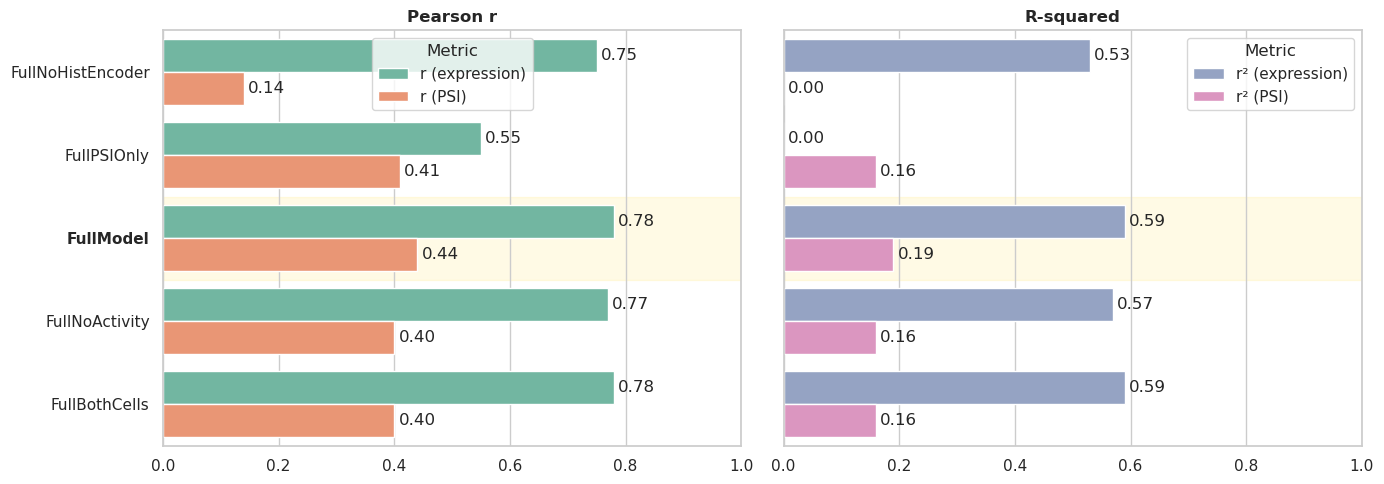

In [21]:
palette = sns.color_palette("Set2", n_colors=4)
palette1 = palette[:2]
palette2 = palette[2:]

fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
axes = ax

pearson_rows = epigen_bp_perf_long[epigen_bp_perf_long["Metric"].isin(['r_expr', 'r_psi'])].copy()
pearson_rows['Metric'] = pearson_rows['Metric'].map({'r_expr': 'r (expression)', 'r_psi': 'r (PSI)'})
sns.barplot(
    data=pearson_rows,
    x="Score", y="Model", ax=axes[0], orient="h",
    hue="Metric", dodge=True, palette=palette1
)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.2f", label_type="edge", padding=3)

model_to_highlight = 'FullModel'
ypos = pearson_rows["Model"].unique().tolist().index(model_to_highlight)

bar_height = 0.5 * len(pearson_rows["Metric"].unique())
main_model = patches.Rectangle(
        (0, ypos - 0.5),          # (x,y) lower-left
        1,                        # full width (since xlim is 0–1)
        bar_height,               # vertical span
        color="gold", alpha=0.1,  # subtle highlight color
        zorder=0                  # behind bars
        )

main_model2 = patches.Rectangle(
        (0, ypos - 0.5),          
        1,                        
        bar_height,               
        color="gold", alpha=0.1,  
        zorder=0                  
        )

# Add rectangle spanning the entire x-axis for that row
axes[0].add_patch(main_model)

yticklabels = axes[0].get_yticklabels()

for label in yticklabels:
    if label.get_text() == model_to_highlight:
        label.set_fontweight("bold")

axes[0].set_yticklabels(yticklabels)

axes[0].set_title("Pearson r", fontsize=12, weight="bold")
axes[0].set_xlim(0, 1)
axes[0].set_xlabel("")
axes[0].set_ylabel("")  # remove redundant label
axes[0].legend(title="Metric", loc="best")

r2_rows = epigen_bp_perf_long[epigen_bp_perf_long["Metric"].isin(['r2_expr', 'r2_psi'])]
r2_rows['Metric'] = r2_rows['Metric'].map({'r2_expr': 'r² (expression)', 'r2_psi': 'r² (PSI)'})
sns.barplot(
    data=r2_rows,
    x="Score", y="Model", ax=axes[1], orient="h",
    hue="Metric", dodge=True, palette=palette2
)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f", label_type="edge", padding=3)

axes[1].add_patch(main_model2)

axes[1].set_title("R-squared", fontsize=12, weight="bold")
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("")
axes[1].set_ylabel("")  # remove redundant label
axes[1].legend(title="Metric", loc="best")

#fig.legend(handles, labels, loc="lower center", ncol=len(labels), frameon=False)
plt.tight_layout()
plt.savefig("../images/bp_epigen_performances.png", dpi=300)
plt.show()

In [22]:
from glob import glob
fm_path_k562 = "2025-09-29-09-24"
fm_path_gm12878 = "2025-09-30-16-11"

def load_preds(date_folder):
    day_folder = date_folder[:10]  # e.g., '2025-07-25'
    csv_files = [f for f in glob(f"../trained_models/{day_folder}/{date_folder}/*.csv") if not f.endswith('losses.csv')]
    loss_file = [f for f in glob(f"../trained_models/{day_folder}/{date_folder}/*losses.csv")][0]
    losses = pd.read_csv(loss_file)
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {date_folder}")
    if len(csv_files) == 1:
        return pd.read_csv(csv_files[0]), losses
    else:
        all_predictions = []
        for pred_file in csv_files:
            df = pd.read_csv(pred_file)
            #if 'Unnamed: 0' in df.columns:
            #    df = df.drop(columns=['Unnamed: 0'])
            # rename Unnamed: 0 to gene_id
            df = df.rename(columns={'Unnamed: 0': 'gene_id'})
            all_predictions.append(df)
        return pd.concat(all_predictions, ignore_index=True), losses
    
k562_preds, _ = load_preds(fm_path_k562)
k562_preds['CellLine'] = 'K562'
gm12878_preds, _ = load_preds(fm_path_gm12878)
gm12878_preds['CellLine'] = 'GM12878'
k562_preds

,gene_id,PredExpr,ActualExpr,CellLine,PredPsi,ActualPsi,fold_idx
0,ENSG00000004776,0.571120,-0.886057,K562,0.982305,1.000000,8
1,ENSG00000004777,1.008309,0.710117,K562,0.943974,1.000000,8
2,ENSG00000004777,1.050576,0.710117,K562,0.928935,1.000000,8
3,ENSG00000004777,1.071740,0.710117,K562,0.970905,1.000000,8
4,ENSG00000005007,1.609972,1.415140,K562,0.978322,1.000000,8
...,...,...,...,...,...,...,...
24933,ENSG00000258289,1.202148,1.893040,K562,0.915137,0.045170,3
24934,ENSG00000258289,1.201500,1.893040,K562,0.912340,0.190956,3
24935,ENSG00000258466,0.849283,-0.397940,K562,0.969956,1.000000,3
24936,ENSG00000258643,1.645904,0.359835,K562,0.949904,1.000000,3


In [23]:
def score_by_fold(k562_preds, se_only=False):
    # per fold calculate metrics
    fold_metrics_df = []

    if se_only:
        se_events = pd.read_csv('../data/psi_response.csv')
        se_events = se_events[se_events['event_id'].str.contains(';SE:')]
        se_genes = set(se_events['gene_id'].unique())
        k562_preds['isSEgene'] = k562_preds['gene_id'].apply(lambda x: x in se_genes)
        k562_preds = k562_preds[k562_preds['isSEgene']]

    for fold, group in k562_preds.groupby('fold_idx'):
        r2_expr = r2_score(group['ActualExpr'], group['PredExpr'])
        r_expr, _ = pearsonr(group['ActualExpr'], group['PredExpr'])

        r2_psi = r2_score(group['ActualPsi'], group['PredPsi'])
        r_psi, _ = pearsonr(group['ActualPsi'], group['PredPsi'])

        fold_metrics_df.append({'fold': fold, 'r_expr': r_expr, 'r2_expr': r2_expr, 'r_psi': r_psi, 'r2_psi': r2_psi})

    r2_expr = r2_score(k562_preds['ActualExpr'], k562_preds['PredExpr'])
    r_expr, _ = pearsonr(k562_preds['ActualExpr'], k562_preds['PredExpr'])
    r2_psi = r2_score(k562_preds['ActualPsi'], k562_preds['PredPsi'])
    r_psi, _ = pearsonr(k562_preds['ActualPsi'], k562_preds['PredPsi'])

    fold_metrics_df.append({'fold': "all", 'r_expr': r_expr, 'r2_expr': r2_expr, 'r_psi': r_psi, 'r2_psi': r2_psi})
    return fold_metrics_df

fold_metrics_df_k = pd.DataFrame(score_by_fold(k562_preds, True))
fold_metrics_df_gm = pd.DataFrame(score_by_fold(gm12878_preds, True))

In [24]:
fold_metrics_df_k['Cell line'] = 'K562'
fold_metrics_df_gm['Cell line'] = 'GM12878'

fold_metrics_df = pd.concat([fold_metrics_df_k, fold_metrics_df_gm])

In [25]:
fold_metrics_df

,fold,r_expr,r2_expr,r_psi,r2_psi,Cell line
0,1,0.532875,0.089261,0.424478,0.140357,K562
1,2,0.517056,0.190986,0.436577,0.172683,K562
2,3,0.567378,0.029092,0.373496,0.082770,K562
3,4,0.455975,-0.174925,0.365728,0.078792,K562
4,5,0.482768,0.130199,0.385241,0.090693,K562
5,6,0.565812,-0.207767,0.367335,0.085964,K562
6,7,0.568788,0.112597,0.368727,0.078311,K562
7,8,0.466919,0.189756,0.353416,0.036266,K562
8,9,0.525581,-0.239918,0.446104,0.165259,K562
9,10,0.574743,0.194391,0.379903,0.118085,K562


In [40]:
# per cell line calculate mean and sd 
result = fold_metrics_df.groupby(['Cell line']).agg({'r_expr': ['mean', 'std'], 'r_psi': ['mean', 'std'], 'r2_expr': ['mean', 'std'], 'r2_psi': ['mean', 'std']}).reset_index()
result = result.T.reset_index()
# set row 0 as columns
headers = ['pred_metric', 'stat', 'GM12878', 'K562']
result.columns = headers
# remove row 0
result = result.iloc[1:].copy()
# merge cell lines into one column
result_melted = result.melt(id_vars=['pred_metric', 'stat'], value_vars=['GM12878', 'K562'], var_name='cell', value_name='value')
result_plot = result_melted.pivot_table(index=['pred_metric', 'cell'], values='value', columns='stat').reset_index()
result_plot['pred_metric'] = result_plot['pred_metric'].map({'r_expr': 'r (expression)', 'r_psi': 'r (PSI)', 'r2_expr': 'R² (expression)', 'r2_psi': 'R² (PSI)'})
result_plot

stat,pred_metric,cell,mean,std
0,R² (expression),GM12878,-0.040683,0.234419
1,R² (expression),K562,0.03462,0.157683
2,R² (PSI),GM12878,0.113091,0.033341
3,R² (PSI),K562,0.108241,0.039556
4,r (expression),GM12878,0.493286,0.051442
5,r (expression),K562,0.531144,0.042444
6,r (PSI),GM12878,0.410565,0.021318
7,r (PSI),K562,0.395474,0.032144


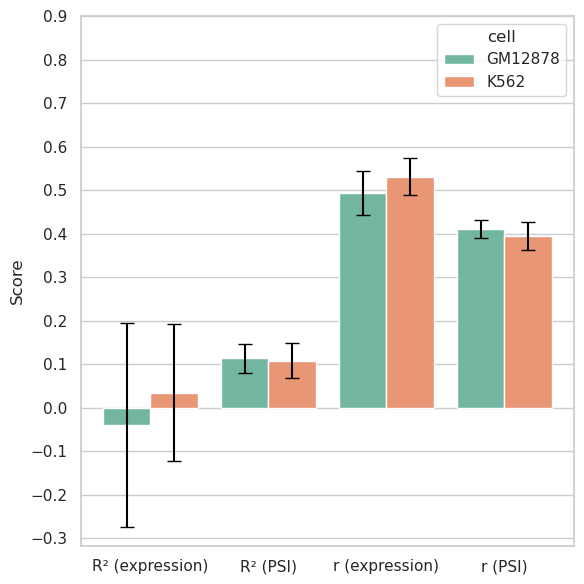

In [46]:
# plot per cell line
fig, axes = plt.subplots(1, 1, figsize=(6, 6))

sns.barplot(x='pred_metric', y='mean', hue='cell', data=result_plot, ax=axes, palette="Set2", errorbar=("ci", 0))

cells = [0, 1, 0, 1, 0, 1, 0, 1]

plt.errorbar(
    x=[i + (j - 0.5)*0.4 for i, j in zip(result_plot['pred_metric'].factorize()[0], cells)],
    y=result_plot['mean'],
    yerr=result_plot['std'],
    fmt='none',
    c='black',
    capsize=5
)
plt.ylabel("Score")
plt.xlabel("")

plt.yticks(np.arange(-0.3, 1, 0.1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

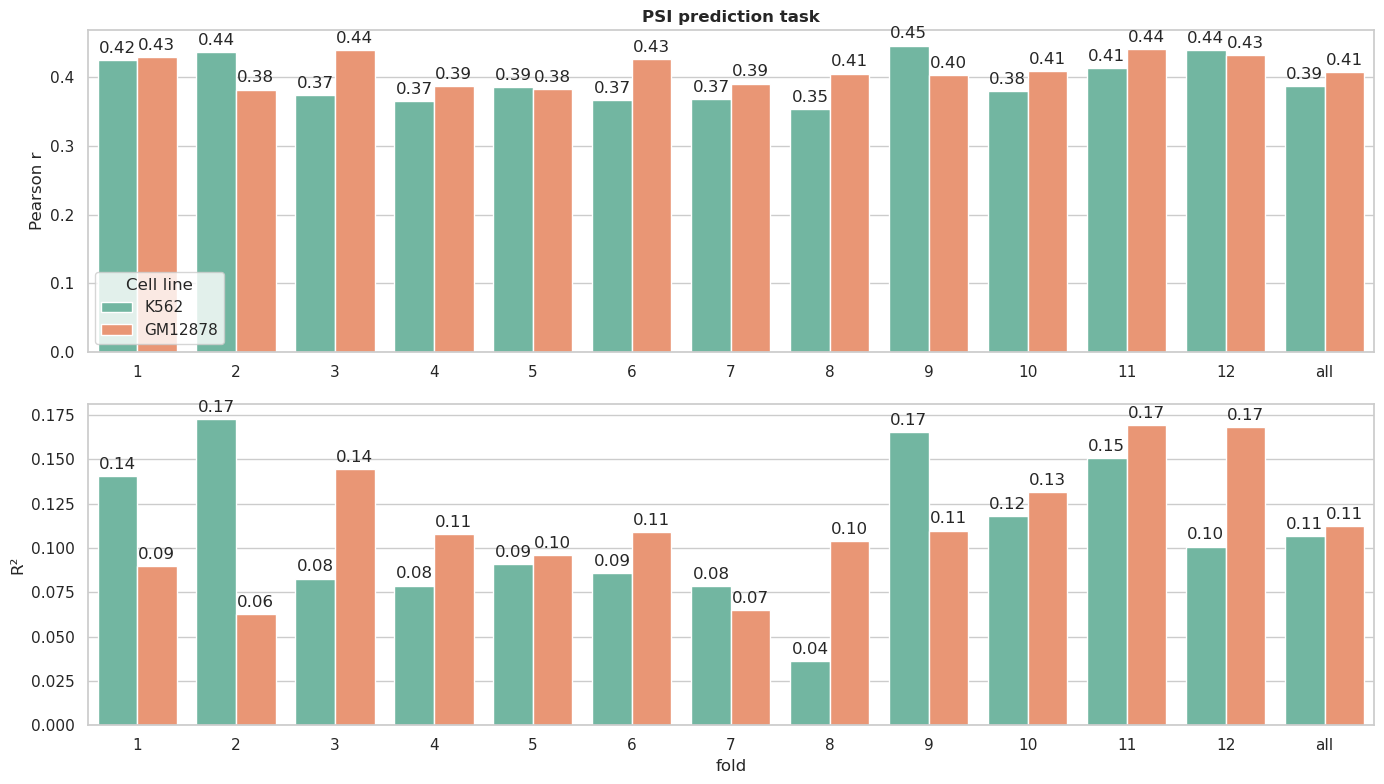

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes = axes.flatten()

pal = sns.color_palette("Set2", n_colors=4)

sns.barplot(x='fold', y='r_psi', hue='Cell line', data=fold_metrics_df, ax=axes[0], palette="Set2")
axes[0].set_xlabel("")
axes[0].set_ylabel("Pearson r")
axes[0].set_title('PSI prediction task', fontsize=12, weight="bold")

for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.2f", label_type="edge", padding=3)


sns.barplot(x='fold', y='r2_psi', hue='Cell line', data=fold_metrics_df, ax=axes[1], palette="Set2")
#axes[1].set_title("R² PSI", fontsize=12, weight="bold")
axes[1].set_ylabel("R²")
axes[1].get_legend().remove()

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f", label_type="edge", padding=3)

plt.tight_layout()
plt.show()

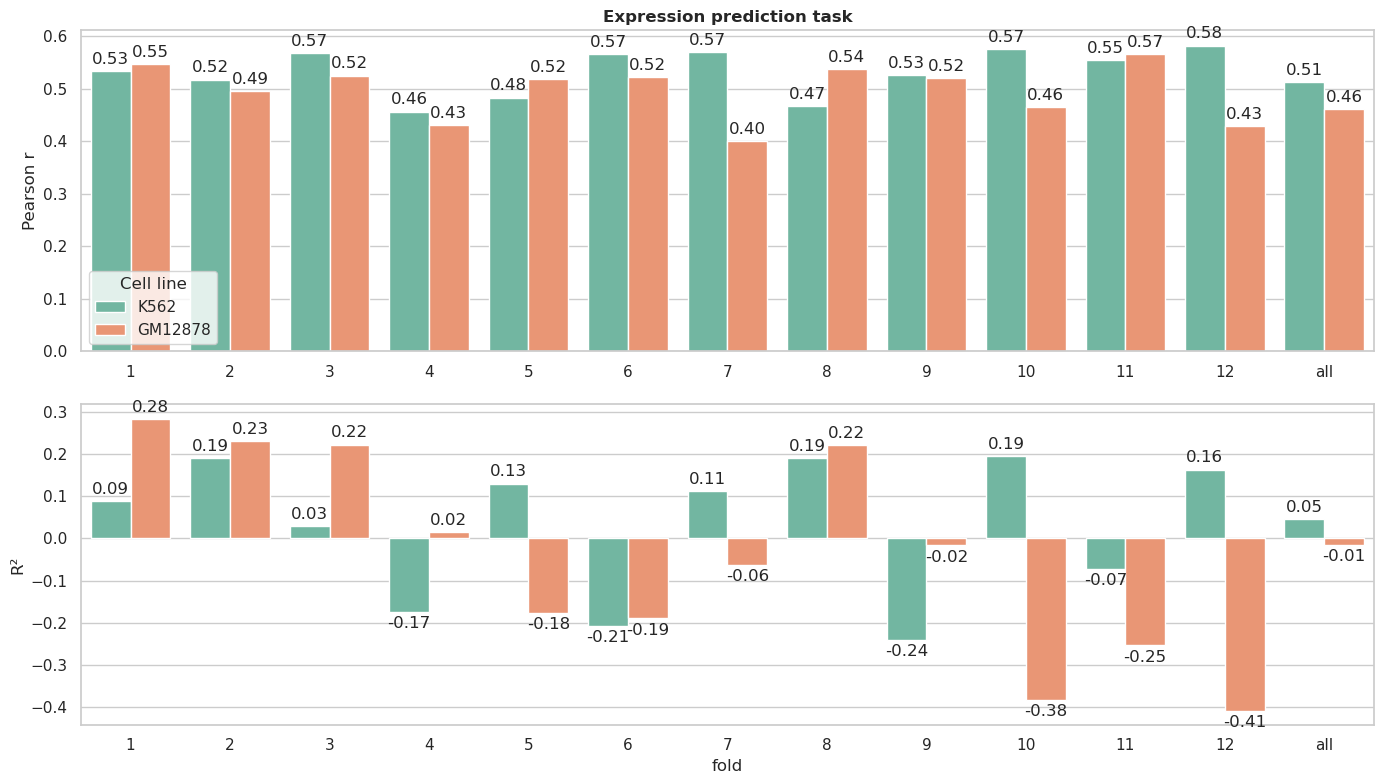

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes = axes.flatten()

pal = sns.color_palette("Set2", n_colors=4)

sns.barplot(x='fold', y='r_expr', hue='Cell line', data=fold_metrics_df, ax=axes[0], palette="Set2")
axes[0].set_xlabel("")
axes[0].set_ylabel("Pearson r")
axes[0].set_title('Expression prediction task', fontsize=12, weight="bold")

for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.2f", label_type="edge", padding=3)


sns.barplot(x='fold', y='r2_expr', hue='Cell line', data=fold_metrics_df, ax=axes[1], palette="Set2")
#axes[1].set_title("R² PSI", fontsize=12, weight="bold")
axes[1].set_ylabel("R²")
axes[1].get_legend().remove()

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f", label_type="edge", padding=3)

plt.tight_layout()
plt.show()

In [30]:
binary_conversion = {
    'K562 full': {'MCC': 0.32, 'ROC AUC': 0.79, 'Balanced Accuracy': 0.65, 'F1 Score': 0.94, 'note': 'cut off 0.7'},
    'GM12878 full': {'MCC': 0.33, 'ROC AUC': 0.79, 'Balanced Accuracy': 0.65, 'F1 Score': 0.94,'note': 'cut off 0.7'},
    'K562 fold1': {'MCC': 0.35, 'ROC AUC': 0.79, 'Balanced Accuracy': 0.67, 'F1 Score': 0.93, 'note': 'cut off 0.7'}                    
}

binary_conversion = pd.DataFrame(binary_conversion)
binary_conversion

,K562 full,GM12878 full,K562 fold1
MCC,0.32,0.33,0.35
ROC AUC,0.79,0.79,0.79
Balanced Accuracy,0.65,0.65,0.67
F1 Score,0.94,0.94,0.93
note,cut off 0.7,cut off 0.7,cut off 0.7


In [31]:
binary_conversion_melted = binary_conversion.reset_index().melt(id_vars="index", var_name="Model", value_name="Score")
binary_conversion_melted.rename(columns={"index": "Metric"}, inplace=True)
binary_conversion_melted

,Metric,Model,Score
0,MCC,K562 full,0.32
1,ROC AUC,K562 full,0.79
2,Balanced Accuracy,K562 full,0.65
3,F1 Score,K562 full,0.94
4,note,K562 full,cut off 0.7
5,MCC,GM12878 full,0.33
6,ROC AUC,GM12878 full,0.79
7,Balanced Accuracy,GM12878 full,0.65
8,F1 Score,GM12878 full,0.94
9,note,GM12878 full,cut off 0.7


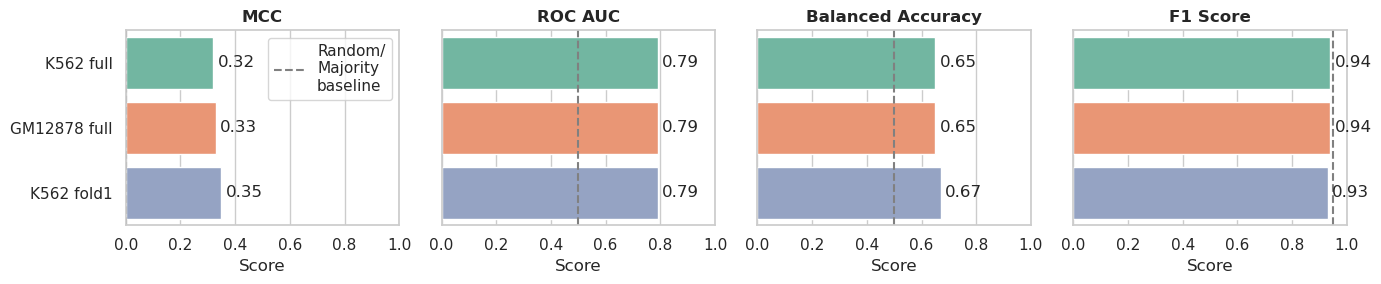

In [32]:
palette = sns.color_palette("Set2", n_colors=binary_conversion_melted["Model"].nunique())
fig, ax = plt.subplots(1, 4, figsize=(14, 3), sharey=True)
axes = ax.flatten()

metrics = binary_conversion_melted["Metric"].unique()

zero_pos = {'MCC': 0, 'ROC AUC': 0.5, 'Balanced Accuracy': 0.5, 'F1 Score': 0.95}

for i, metric in enumerate(metrics):
    if metric == 'note':
        continue
    ax = axes[i]
    sns.barplot(
        data=binary_conversion_melted[binary_conversion_melted["Metric"] == metric],
        x="Score", y="Model", ax=ax, orient="h",
        hue="Model", dodge=False, palette=palette
    )
    ax.set_title(metric, fontsize=12, weight="bold")
    ax.set_xlim(0, 1)
    ax.set_xlabel("Score")
    ax.set_ylabel("")  # remove redundant label
    ax.axvline(zero_pos[metric], color="gray", linestyle="--", label="Random/\nMajority\nbaseline")
    #ax.legend([],[], frameon=False)
    if metric == 'MCC':
        ax.legend()
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", label_type="edge", padding=3)

handles, labels = ax.get_legend_handles_labels()
#fig.legend(handles, labels, loc="lower center", ncol=len(labels), frameon=False)

plt.tight_layout()
plt.savefig("../images/full_binarized_performances.png", dpi=300)
plt.show()

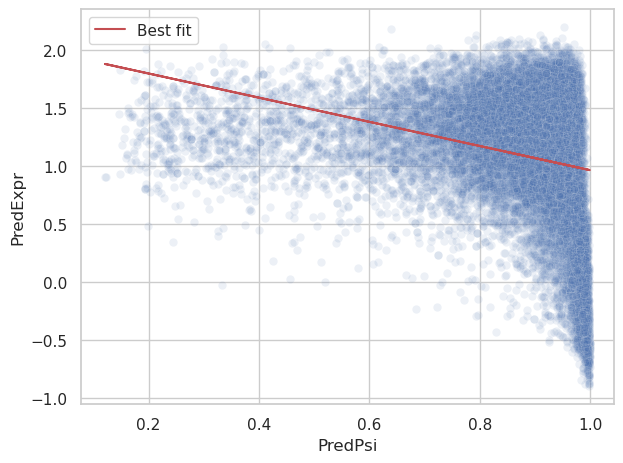

In [33]:
# print scatter 
sns.scatterplot(k562_preds, x='PredPsi', y='PredExpr', alpha=0.1)
# get a best fit line
z = np.polyfit(k562_preds['PredPsi'], k562_preds['PredExpr'], 1)
p = np.poly1d(z)
plt.plot(k562_preds['PredPsi'], p(k562_preds['PredPsi']), "r", label='Best fit')
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
fold_metrics_df

,fold,r_expr,r2_expr,r_psi,r2_psi,Cell line
0,1,0.532875,0.089261,0.424478,0.140357,K562
1,2,0.517056,0.190986,0.436577,0.172683,K562
2,3,0.567378,0.029092,0.373496,0.082770,K562
3,4,0.455975,-0.174925,0.365728,0.078792,K562
4,5,0.482768,0.130199,0.385241,0.090693,K562
5,6,0.565812,-0.207767,0.367335,0.085964,K562
6,7,0.568788,0.112597,0.368727,0.078311,K562
7,8,0.466919,0.189756,0.353416,0.036266,K562
8,9,0.525581,-0.239918,0.446104,0.165259,K562
9,10,0.574743,0.194391,0.379903,0.118085,K562


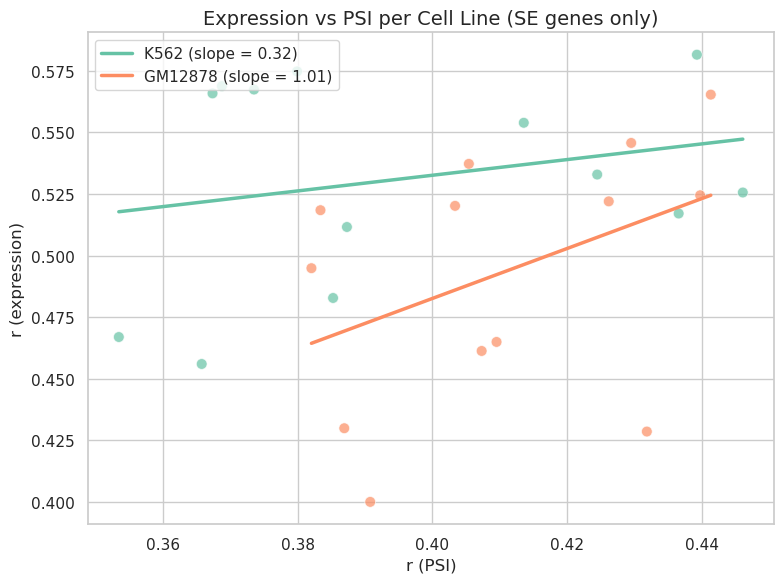

In [47]:
plt.figure(figsize=(8, 6))

# consistent color palette
palette = sns.color_palette("Set2", n_colors=fold_metrics_df['Cell line'].nunique())

# scatterplot
sns.scatterplot(
    data=fold_metrics_df,
    x='r_psi', y='r_expr',
    hue='Cell line',
    palette=palette,
    alpha=0.7,
    s=60,
    legend=False  # we'll add our own legend
)

# add regression lines with coefficients in legend
handles = []
labels = []
for cell_line, color in zip(fold_metrics_df['Cell line'].unique(), palette):
    subset = fold_metrics_df[fold_metrics_df['Cell line'] == cell_line]
    slope, intercept = np.polyfit(subset['r_psi'], subset['r_expr'], 1)
    x_range = np.linspace(subset['r_psi'].min(), subset['r_psi'].max(), 100)
    y_fit = np.polyval([slope, intercept], x_range)
    line, = plt.plot(
        x_range, y_fit,
        color=color,
        lw=2.5,
        label=f"{cell_line} (slope = {slope:.2f})"
    )
    handles.append(line)
    labels.append(line.get_label())

plt.title("Expression vs PSI per Cell Line (SE genes only)", fontsize=14)
plt.xlabel("r (PSI)")
plt.ylabel("r (expression)")
plt.legend(handles=handles, labels=labels,loc="upper left")
plt.tight_layout()
plt.show()